In [1]:
%load_ext autoreload
%autoreload 2

from subareas import Subareas
from subarea_calculations import Subarea_Calculations

from climada.hazard import TCTracks, Centroids, TropCyclone
from climada.entity import LitPop
from climada.entity import ImpfSetTropCyclone


### Set CAT Bond Basics

In [2]:
### Bond Basics ###
country = 659  # St. Kitts and Nevis
exhaustion_point = '0.5 Exp' # 50% of exposure
attachment_point = '0.05 Exp' # 5% of exposure
term = 3  # years
par_index = 60 # statistic for parametric index (e.g. 60 for 60th percentile)

### Subarea Basics ###
grid_specs=[1,2] # 3x3 grid
buffer_grid_size=0.5 # km of buffer around exposure
min_pol_size=100 # minimum subarea size in m² 

### Pricing Basics ###
peak_peril = 0 # indicator if its considered peak peril (1) or not (0)
target_sharpe = 0.5 # target Sharpe ratio
risk_free_rate = 0.0  # risk free rate for Sharpe ratio and return calculation

### Define Exposure, Hazard, and Vulnerability

2024-01-01 01:07:04,151 - climada.hazard.tc_tracks - INFO - Progress: 100%
2024-01-01 01:07:04,226 - climada.hazard.tc_tracks - INFO - Interpolating 1 tracks to 1h time steps.
2024-01-01 01:07:04,283 - climada.hazard.tc_tracks_synth - INFO - Computing 50 synthetic tracks.


<string>:7: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.


2024-01-01 01:07:10,805 - climada.util.coordinates - INFO - Sampling from /Users/kbergmueller/climada/data/GMT_intermediate_coast_distance_01d.tif
2024-01-01 01:07:10,860 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Mapping 51 tracks to 546 coastal centroids.
2024-01-01 01:07:11,290 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 11%
2024-01-01 01:07:11,792 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 23%
2024-01-01 01:07:12,186 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 35%
2024-01-01 01:07:12,598 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 47%
2024-01-01 01:07:12,970 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 58%
2024-01-01 01:07:13,488 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 70%
2024-01-01 01:07:13,908 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 82%
2024-01-01 01:07:14,263 - climada.hazard.trop_cyclone.trop_cyclone - INFO - Progress: 94%
2024-01-01 01

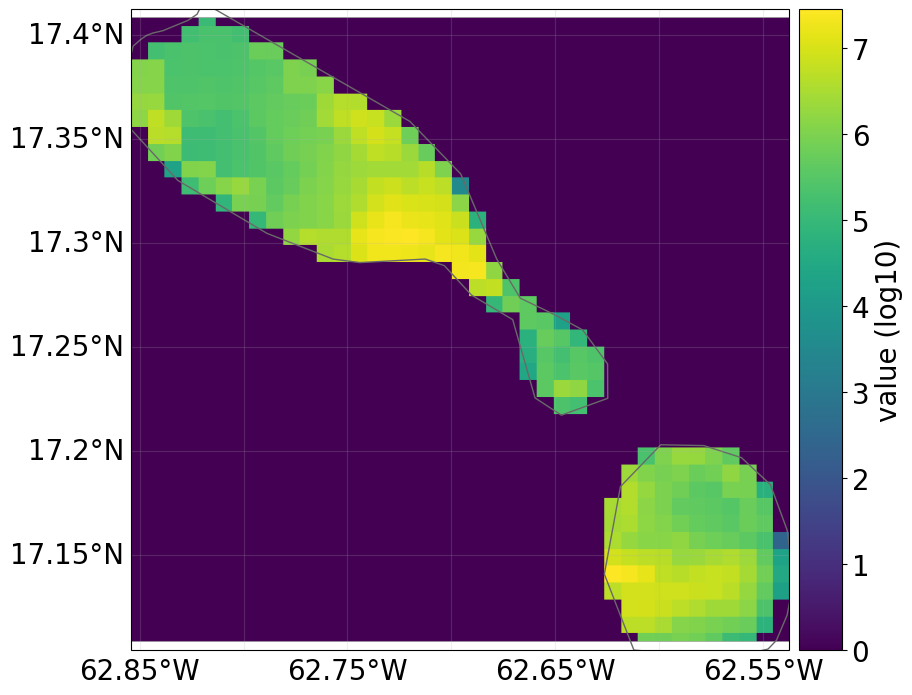

In [3]:
tr_irma = TCTracks.from_ibtracs_netcdf(
    provider="usa", storm_id="2017242N16333"
)  # IRMA 2017
tr_irma.equal_timestep()
tr_irma.calc_perturbed_trajectories(nb_synth_tracks=50)
min_lat, max_lat, min_lon, max_lon = 17.0, 17.5, -62.9, -62.5
cent = Centroids.from_pnt_bounds((min_lon, min_lat, max_lon, max_lat), res=0.02)

# construct tropical cyclones
tc_irma = TropCyclone.from_tracks(tr_irma, centroids=cent)


exp = LitPop.from_countries(
        [str(country)], fin_mode='gdp', reference_year=2020
    )
exp.plot_raster()
impfset = ImpfSetTropCyclone.from_calibrated_regional_ImpfSet()
iso3n_per_region = impf_id_per_region = impfset.get_countries_per_region()[2]
exp.gdf.loc[exp.gdf.region_id == country, 'impf_TC'] = 1

### Initialise Subarea Class

                                            geometry subarea_letter
0  POLYGON ((-62.53301 17.10417, -62.53303 17.103...              A
1  POLYGON ((-62.53301 17.15265, -62.63247 17.152...              B
2  POLYGON ((-62.62348 17.22756, -62.62351 17.227...              C
3  POLYGON ((-62.79988 17.41679, -62.79944 17.416...              D


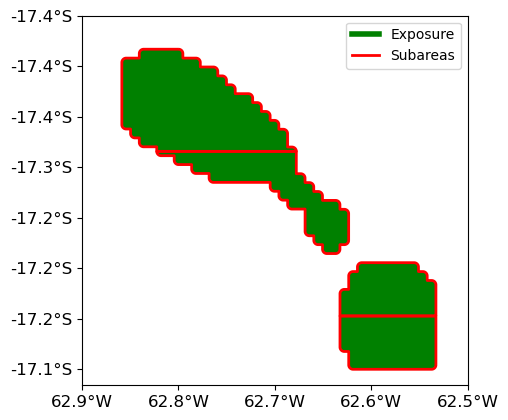

In [4]:
st_kitts_subareas = Subareas(tc_irma, impfset, exp, grid_specs=grid_specs, buffer_grid_size=buffer_grid_size, min_pol_size=min_pol_size)
print(st_kitts_subareas.subareas_gdf)
st_kitts_subareas.plot()

### Subarea Calculations

2024-01-01 01:11:25,220 - climada.entity.exposures.base - INFO - Matching 328 exposures with 546 centroids.
2024-01-01 01:11:25,227 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 100
2024-01-01 01:11:25,231 - climada.engine.impact_calc - INFO - Calculating impact for 984 assets (>0) and 51 events.


2024-01-01 01:11:27,803 INFO subarea_calculations: The attachment point and the principal of the CAT bond is: 52650000.0 and 526500000.0 [USD], respectively.
2024-01-01 01:11:27,803 INFO subarea_calculations: Attachment point and principal as share of exposure: 0.05 and 0.5, respectively.


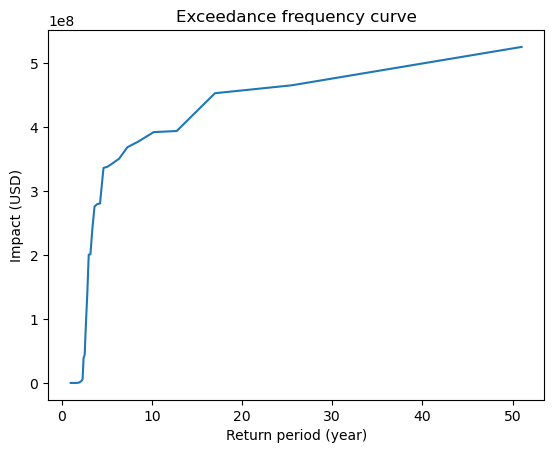

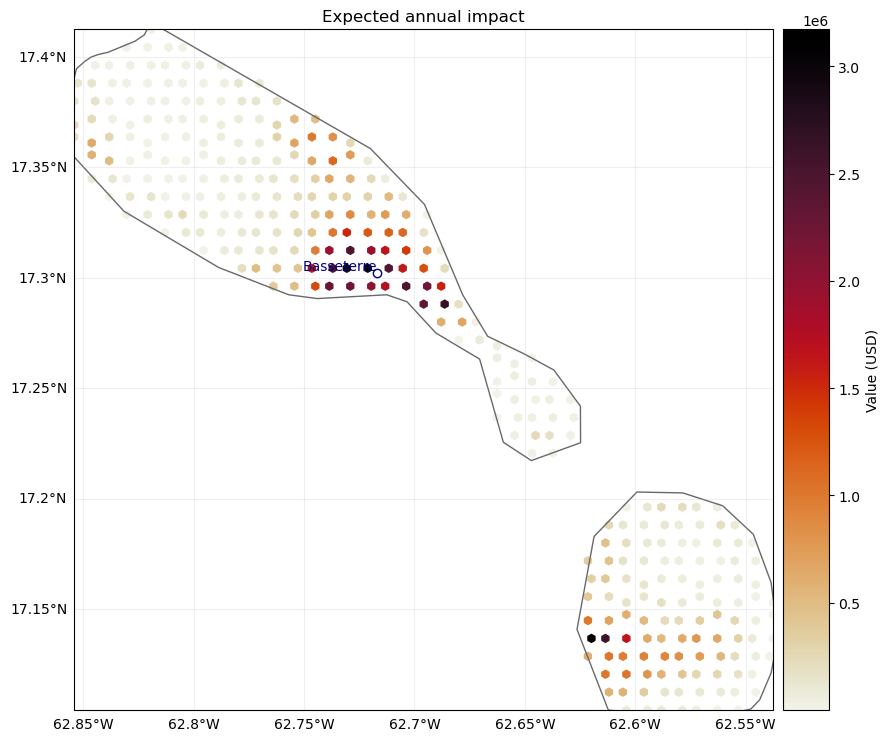

In [6]:
st_kitts_sub_calc = Subarea_Calculations(subareas=st_kitts_subareas, index_stat=par_index, exhaustion_point=exhaustion_point, attachment_point=attachment_point)
imp, imp_per_event, imp_subareas_evt = st_kitts_sub_calc._calc_impact()
# Compute exceedance frequency curve
freq_curve = imp.calc_freq_curve()
freq_curve.plot()
imp.plot_hexbin_eai_exposure(gridsize=100, adapt_fontsize=False)
par_idx = st_kitts_sub_calc._calc_index()
principal, attachment = st_kitts_sub_calc._calc_attachment_principal(imp)
results, opt_min_thresh, opt_max_thresh = st_kitts_sub_calc._calibrate_payout_fcts(par_idx, principal, attachment, imp_subareas_evt)
pay_vs_dam = st_kitts_sub_calc._calc_pay_vs_dam(imp_per_event=imp_per_event, imp_subareas_evt=imp_subareas_evt, attachment=attachment, principal=principal, opt_min_thresh=opt_min_thresh, opt_max_thresh=opt_max_thresh, haz_int=par_idx)